# Precipitation (Part 2) - Masked Time Series and Ensemble Hovmoller

## Inset (Global Importation and Load Data)

In [3]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


In [4]:
model = 'UKESM1-0-LL'
model_short = 'UKESM'
path_figure = f"/home/users/alvin_ch/figures/Multi-model/{model_short}/Precip/"
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Precip/"

filename = "interpolated_obs_grid.nc"
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

interpolated_model_files = {}

for ens in ensemble_members:
    interpolated_model_files[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

In [5]:
obs_gen = 'GPCP'
var = 'pr'
filename = 'gpcp_v02r03_monthly_197901_202312.nc'
obs_path = f"/home/users/speatier/DATA/Obs/{var}/{obs_gen}/{filename}"

obs_file = xr.open_mfdataset(obs_path, combine='by_coords', use_cftime=True)

In [6]:
obs_2_gen = 'CRU'
filename = 'cru_ts4.10.1901.2025.pre.dat.nc'
obs_2_path = f"/home/users/speatier/DATA/Obs/{var}/{obs_2_gen}/{filename}"

obs_2_file = xr.open_mfdataset(obs_2_path, combine='by_coords', use_cftime=True)

In [7]:
obs_2_file = obs_2_file.rename({'lon': 'longitude', 'lat': 'latitude'})
obs_2_file

<xarray.Dataset> Size: 8GB
Dimensions:    (longitude: 720, latitude: 360, time: 1500)
Coordinates:
  * longitude  (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * latitude   (latitude) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * time       (time) object 12kB 1901-01-16 00:00:00 ... 2025-12-16 00:00:00
Data variables:
    pre        (time, latitude, longitude) float32 2GB dask.array<chunksize=(1500, 360, 720), meta=np.ndarray>
    stn        (time, latitude, longitude) float64 3GB dask.array<chunksize=(1500, 360, 720), meta=np.ndarray>
    mae        (time, latitude, longitude) float32 2GB dask.array<chunksize=(1500, 360, 720), meta=np.ndarray>
    maea       (time, latitude, longitude) float32 2GB dask.array<chunksize=(1500, 360, 720), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.10 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2604091129. Data generated from:pre.2604081855.dtb
    history:      Thu  9 Apr 14:20:33 BST 2026 : User sadmin : Program makegr...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

## Seasonal Mean Over Time

In [8]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

In [9]:
# Similar function.
# Tweaked due to different variable names.
def seasonal_average_over_years_MJJAS_obs(data):

    # Convert numeric time into datetime.
    time_str = data.time.values.astype(str)
    dates = pd.to_datetime([x.split('.')[0] for x in time_str], format='%Y%m%d')
    data = data.assign_coords(time=dates)
    
    # Select May-September
    data_mjjas = data.sel(time=data.time.dt.month.isin([5, 6, 7, 8, 9]))

    # Create annual MJJAS averages
    seasonal_avg = data_mjjas.groupby('time.year').mean('time')
    return seasonal_avg

In [10]:
def convert_midmonth_cftime_to_datetime64(ds):
    t = ds['time'].values

    # Convert CFTime into Python datetime manually
    py_dt = np.array([datetime.datetime(ti.year, ti.month, ti.day) for ti in t])

    # Convert Python datetime into numpy datetime64
    dt64 = py_dt.astype('datetime64[ns]')
    return ds.assign_coords(time=dt64)


def convert_mm_month_to_mm_day(ds, variable):
    # Days in each month
    days = ds['time'].dt.days_in_month

    # Convert
    ds = ds.assign({variable: ds[variable] / days})
    return ds


def seasonal_MJJAS_obs_2(ds):
    ds_mjjas = ds.sel(time=ds.time.dt.month.isin([5,6,7,8,9]))
    mean_val = ds_mjjas.mean(skipna=True).compute()
    return ds_mjjas.groupby('time.year').mean('time', skipna=True)

In [11]:
obs_2_time_converted = convert_midmonth_cftime_to_datetime64(obs_2_file)
obs_2_time_unit_converted = convert_mm_month_to_mm_day(obs_2_time_converted, 'pre')
test = seasonal_MJJAS_obs_2(obs_2_time_unit_converted)


# Check that we have successfully converted units.
test1 = obs_2_time_unit_converted['pre']
print('NaN Values =', test1.isnull().sum().compute())

test2 = test['pre']
print('NaN Values =', test2.isnull().sum().compute())

NaN Values = <xarray.DataArray 'pre' ()> Size: 8B
array(287670000)
NaN Values = <xarray.DataArray 'pre' ()> Size: 8B
array(23972500)


## Masked Time Series

### Define Boxes

In [12]:
import shapely.geometry as sgeom

def lon360_to_180(lon):
    return ((lon + 180) % 360) - 180

# Define box limits.
# Overview
test_lon_min, test_lon_max = lon360_to_180(335.0), lon360_to_180(33.0)   # degrees
test_lat_min, test_lat_max = 0.0, 20.0                                   # degrees

# Define polygon (anti-clockwise order)
test_poly = sgeom.Polygon([
    (test_lon_min, test_lat_min),  # SW corner
    (test_lon_max, test_lat_min),  # SE corner
    (test_lon_max, test_lat_max),  # NE corner
    (test_lon_min, test_lat_max),  # NW corner
])

# Sahel
sahel_lon_min, sahel_lon_max = lon360_to_180(350.0), lon360_to_180(20.0)   # degrees
sahel_lat_min, sahel_lat_max = 10.0, 20.0                                  # degrees

sahel_poly = sgeom.Polygon([
    (sahel_lon_min, sahel_lat_min),  # SW corner
    (sahel_lon_max, sahel_lat_min),  # SE corner
    (sahel_lon_max, sahel_lat_max),  # NE corner
    (sahel_lon_min, sahel_lat_max),  # NW corner
])

# Mid-coast
# This box requires masking as it lies between the coast and continent.
coast_lon_min, coast_lon_max = lon360_to_180(340.0), lon360_to_180(20.0)   # degrees
coast_lat_min, coast_lat_max = -0.0, 10.0                                  # degrees

coast_poly = sgeom.Polygon([
    (coast_lon_min, coast_lat_min),  # SW corner
    (coast_lon_max, coast_lat_min),  # SE corner
    (coast_lon_max, coast_lat_max),  # NE corner
    (coast_lon_min, coast_lat_max),  # NW corner
])

In [13]:
regions = {"overall": test_poly, "sahel": sahel_poly, "west_coast": coast_poly}

region_colors = {'overall': 'green', 'sahel': 'red', 'west_coast': 'blue'}
region_labels = True

regions_list = ['overall', 'sahel', 'west_coast']
seas_list = ['MJJAS']

In [14]:
def polygon_mask(ds, polygon, lon_name="longitude", lat_name="latitude"):
    """
    Works for 1-D lon and lat (regular grids).
    Produces mask with dims (lat, lon).
    """

    lon = ds[lon_name].values        # shape (192,)
    lat = ds[lat_name].values        # shape (144,)

    # Build 2D coordinate grid
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Check each grid point
    points = [sgeom.Point(x, y) for x, y in zip(lon2d.ravel(), lat2d.ravel())]
    inside = np.array([polygon.covers(pt) for pt in points])

    mask = inside.reshape(lat2d.shape)   # shape (144, 192)

    # Return DataArray with correct dims and coords
    return xr.DataArray(
        mask,
        dims=(ds[lat_name].dims[0], ds[lon_name].dims[0]),
        coords={ds[lat_name].dims[0]: ds[lat_name],
                ds[lon_name].dims[0]: ds[lon_name]}
    )

### Weighted Average

In [15]:
# This implementation is also used in the time series with land-sea mask applied.
def area_weighted_avg_masked(data):
    import numpy as np
    
    # Latitude weights: cosine of lat in radians
    lat_rad = np.radians(data['latitude'])
    lat_weights = np.cos(lat_rad)
    
    # Broadcast lat weights to full spatial dims
    # Assuming data dims: ('time', 'lat', 'lon') or similar
    weights = lat_weights.broadcast_like(data.isel(year=0))
    
    # Create a mask of valid (non-NaN) data points
    valid_mask = ~np.isnan(data)
    
    # Apply mask to weights (weights are zero where data is invalid)
    weights_masked = weights * valid_mask
    
    # Normalize weights so they sum to 1 along spatial dims for each time (or other dims)
    weights_sum = weights_masked.sum(dim=['latitude', 'longitude'])
    
    # Avoid division by zero (where weights_sum == 0)
    weights_sum = weights_sum.where(weights_sum != 0)
    
    # Compute weighted average
    weighted_avg = (data * weights_masked).sum(dim=['latitude', 'longitude']) / weights_sum
    return weighted_avg

### Implementation 5a (Land-Sea Mask)

In [16]:
path_mask = "/home/users/speatier/DATA/TIPMIP/UKESM1-0-LL/sftlf_fx_UKESM1-0-LL_piControl_r1i1p1f2_gn.nc"
file_mask = xr.open_mfdataset(path_mask, combine='by_coords')
file_mask

<xarray.Dataset> Size: 119kB
Dimensions:   (lat: 144, bnds: 2, lon: 192)
Coordinates:
  * lat       (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon       (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    type      |S4 4B ...
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds  (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    sftlf     (lat, lon) float32 111kB dask.array<chunksize=(144, 192), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   39600.0
    branch_time_in_parent:  39600.0
    creation_date:          2019-07-04T21:31:24Z
    ...                     ...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/4a2f7b6f-f63b-4f19-895d-0342b776c5de
    variable_id:            sftlf
    variant_label:          r1i1p1f2
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0

In [17]:
# Load regridded land-sea mask.
path_mask = f"{path_files}land_sea_mask_regrid.nc"
file_mask = xr.open_mfdataset(path_mask, combine='by_coords')
file_mask

<xarray.Dataset> Size: 44kB
Dimensions:         (longitude: 144, bnds: 2, latitude: 72)
Coordinates:
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
Dimensions without coordinates: bnds
Data variables:
    longitude_bnds  (longitude, bnds) float32 1kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    latitude_bnds   (latitude, bnds) float32 576B dask.array<chunksize=(72, 2), meta=np.ndarray>
    sftlf           (latitude, longitude) float32 41kB dask.array<chunksize=(72, 144), meta=np.ndarray>
Attributes: (12/48)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.7 CMIP-6.2
    source:                 UKESM1.0-LL (2018): \naerosol: UKCA-GLOMAP-mode\n...
    institution:            Met Office Hadley Centre, Fitzroy Road, Exeter, D...
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    tracking_id:            hdl:21.14100/4a2f7b6f-f63b-4f19-895d-0342b776c5de
    variable_id:            sftlf
    variant_label:          r1i1p1f2
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0
    CDO:                    Climate Data Operators version 2.5.0 (https://mpi...

In [18]:
# Create a boolean mask where land = True (i.e., land fraction < threshold)
land_masked = file_mask['sftlf'] < 50   # threshold: less than 50% land = ocean
ocean_masked = file_mask['sftlf'] > 50  # threshold: more than 50% land = land

In [19]:
print(ocean_masked.sum().compute())

<xarray.DataArray 'sftlf' ()> Size: 8B
array(3477)


### Compute Ensemble Mean

In [20]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='pr'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [21]:
time_series_ens_mean = compute_ensemble_mean(ensemble_members, interpolated_model_files)
time_series_ens_mean

<xarray.DataArray 'pr' (time: 1980, latitude: 72, longitude: 144)> Size: 82MB
dask.array<mean_agg-aggregate, shape=(1980, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 16kB 1850-01-16 00:00:00 ... 2014-12-16 00:00:00
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75

### Compute Weighted Average

In [22]:
# Same-ish code as the demonstration without the land-sea mask.
masked_box_avg = {}
ens1 = 'r1i1p1f1'
ens2 = 'r2i1p1f1'
ens3 = 'r3i1p1f1'
ens4 = 'r4i1p1f1'
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Precip/"

raw_obs_data_1 = obs_file
raw_obs_data_2 = obs_2_time_unit_converted

files_avg = [interpolated_model_files[ens1],
             interpolated_model_files[ens2],
             interpolated_model_files[ens3],
             interpolated_model_files[ens4],
             time_series_ens_mean,
             raw_obs_data_1,
             raw_obs_data_2]

box_avg_names = [ens1, ens2, ens3, ens4, 'ensemble_mean', 'obs_1', 'obs_2']
masked_avg_file_names = [f'{path_files}{ens1}_masked_regional_averaged_MJJAS.nc',
                         f'{path_files}{ens2}_masked_regional_averaged_MJJAS.nc',
                         f'{path_files}{ens3}_masked_regional_averaged_MJJAS.nc',
                         f'{path_files}{ens4}_masked_regional_averaged_MJJAS.nc',
                         f'{path_files}ensemble_mean_masked_reg_averaged_MJJAS.nc',
                         f'{path_files}obs_masked_regional_averaged_MJJAS.nc',
                         f'{path_files}obs_2_masked_regional_averaged_MJJAS.nc']

for file_in, names, file_out in zip(files_avg, box_avg_names, masked_avg_file_names):
    data = file_in

    if names == 'obs_1':
        variable = 'precip'
    elif names == 'obs_2':
        variable = 'pre'
    else:
        variable = 'pr'

    # Masking the ocean.
    data_ls = data.where(ocean_masked)
    """
    # Chunk obs_2 to avoid loading everything at once.
    if names == 'obs_2':
        data_ls = data_ls.chunk({'time': 12})
    """
    masked_box_avg[names] = {}

    for reg in regions_list:
        if names == 'obs_2' and reg == 'west_coast':
            masked_box_avg[names][reg] = None
            continue
        else:
            # Polygon Mask before seasonal averaging.
            region_mask = polygon_mask(data_ls, regions[reg])
            data_reg = data_ls.where(region_mask)

        # Monsoonal Mean on the already region-masked data.
        if names == 'obs_1':
            seas_avg_data = seasonal_average_over_years_MJJAS_obs(data_reg)
        elif names == 'obs_2':
            seas_avg_data = seasonal_MJJAS_obs_2(data_reg)
        else:
            seas_avg_data = seasonal_average_over_years_customed_MJJAS(data_reg)

        # Weighted Average.
        if names == 'ensemble_mean':
            avg_reg = area_weighted_avg_masked(seas_avg_data)
        else:
            avg_reg = area_weighted_avg_masked(seas_avg_data[variable])
    
        avg_reg = avg_reg.rename(variable)
        masked_box_avg[names][reg] = avg_reg

        save_name = f"{file_out.replace('.nc','')}_{reg}.nc"
        # avg_reg.to_netcdf(save_name)

In [23]:
# Check that we have masked and computed successfully.
value_check = masked_box_avg['obs_2']['overall']
print('NaN Values =', value_check.isnull().sum().compute())

NaN Values = <xarray.DataArray 'pre' ()> Size: 8B
array(0)


In [24]:
value_check.values

array([3.94999995, 3.82004311, 3.82823465, 3.72769402, 3.85345617,
       3.91909892, 3.65151383, 3.83782147, 4.07522568, 3.9138063 ,
       3.77436586, 3.70968367, 3.33020693, 3.65183015, 3.83413373,
       4.01940273, 4.04096053, 3.8590627 , 3.80842225, 4.03836468,
       3.97224616, 3.98007081, 3.99282227, 3.85570217, 3.81013346,
       3.91697501, 3.84980558, 4.09645327, 4.09966047, 3.8939393 ,
       4.0758856 , 3.82035228, 4.14959033, 4.20772712, 4.06502097,
       3.99919176, 3.83977858, 4.01534737, 4.01347822, 3.7595351 ,
       3.87901314, 3.83521586, 3.97137785, 3.73821281, 4.07960595,
       4.16241353, 4.20294439, 3.95754284, 3.92946998, 4.34571795,
       3.97031332, 4.22042528, 4.20177648, 4.28846596, 4.2998092 ,
       3.87531389, 4.21356139, 3.79809142, 4.13382831, 4.00413834,
       4.19876223, 4.35536621, 4.14056333, 4.16194747, 3.90734019,
       4.06042869, 3.94944588, 4.08236183, 3.95591507, 3.93978752,
       3.80181893, 3.50031709, 3.50795743, 4.03137813, 3.93375

In [25]:
# All regional averaged file paths.
masked_obs_1_avg_reg = [f'{path_files}obs_masked_regional_averaged_MJJAS_overall.nc',
                        f'{path_files}obs_masked_regional_averaged_MJJAS_sahel.nc',
                        f'{path_files}obs_masked_regional_averaged_MJJAS_west_coast.nc']

masked_obs_2_avg_reg = [f'{path_files}obs_2_masked_regional_averaged_MJJAS_overall.nc',
                        f'{path_files}obs_2_masked_regional_averaged_MJJAS_sahel.nc',
                        f'{path_files}obs_2_masked_regional_averaged_MJJAS_west_coast.nc']

masked_ens_mean_avg_reg = [f'{path_files}ensemble_mean_masked_reg_averaged_MJJAS_overall.nc',
                           f'{path_files}ensemble_mean_masked_reg_averaged_MJJAS_sahel.nc',
                           f'{path_files}ensemble_mean_masked_reg_averaged_MJJAS_west_coast.nc']

masked_ens1_avg_reg = [f'{path_files}{ens1}_masked_regional_averaged_MJJAS_overall.nc',
                       f'{path_files}{ens1}_masked_regional_averaged_MJJAS_sahel.nc',
                       f'{path_files}{ens1}_masked_regional_averaged_MJJAS_west_coast.nc']

masked_ens2_avg_reg = [f'{path_files}{ens2}_masked_regional_averaged_MJJAS_overall.nc',
                       f'{path_files}{ens2}_masked_regional_averaged_MJJAS_sahel.nc',
                       f'{path_files}{ens2}_masked_regional_averaged_MJJAS_west_coast.nc']

masked_ens3_avg_reg = [f'{path_files}{ens3}_masked_regional_averaged_MJJAS_overall.nc',
                       f'{path_files}{ens3}_masked_regional_averaged_MJJAS_sahel.nc',
                       f'{path_files}{ens3}_masked_regional_averaged_MJJAS_west_coast.nc']

masked_ens4_avg_reg = [f'{path_files}{ens4}_masked_regional_averaged_MJJAS_overall.nc',
                       f'{path_files}{ens4}_masked_regional_averaged_MJJAS_sahel.nc',
                       f'{path_files}{ens4}_masked_regional_averaged_MJJAS_west_coast.nc']

# Lists for loop.
regions_list = ['overall', 'sahel', 'west_coast']
box_avg_names = [ens1, ens2, ens3, ens4, 'ensemble_mean', 'obs_1', 'obs_2']
all_files_list = [masked_ens1_avg_reg,
                  masked_ens2_avg_reg,
                  masked_ens3_avg_reg,
                  masked_ens4_avg_reg,
                  masked_ens_mean_avg_reg,
                  masked_obs_1_avg_reg,
                  masked_obs_2_avg_reg]

# New dictionaries for plotting.
masked_overall_avg = {}
masked_sahel_avg = {}
masked_west_coast_avg = {}

for files, name in zip(all_files_list, box_avg_names):
    masked_overall_avg[name] = xr.open_mfdataset(files[0], combine='by_coords')
    masked_sahel_avg[name] = xr.open_mfdataset(files[1], combine='by_coords')
    masked_west_coast_avg[name] = xr.open_mfdataset(files[2], combine='by_coords')

### Convert Units

In [26]:
def convert_units(da, name):
    # Observations already in mm/day
    if name == 'obs_1':
        return da
    elif name == 'obs_2':
        return da
    else:
        # Model data is in kg/m2/s convert to mm/day
        return da * 86400

In [27]:
for name in box_avg_names:
    masked_overall_avg[name] = convert_units(masked_overall_avg[name], name)
    masked_sahel_avg[name] = convert_units(masked_sahel_avg[name], name)
    masked_west_coast_avg[name] = convert_units(masked_west_coast_avg[name], name)

In [28]:
masked_overall_avg[ensemble_members[0]]['year']

<xarray.DataArray 'year' (year: 164)> Size: 1kB
array([1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861,
       1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873,
       1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885,
       1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897,
       1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909,
       1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921,
       1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933,
       1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945,
       1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957,
       1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
       1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013])
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013

### Compute Bias

In [29]:
# Compute Anomalies.
# Difference between ensemble mean and observations.
masked_bias_avg_reg_1 = {}
masked_bias_avg_reg_2 = {}

# File paths.
masked_obs_1_avg_reg = [f'{path_files}obs_masked_regional_averaged_MJJAS_overall.nc',
                        f'{path_files}obs_masked_regional_averaged_MJJAS_sahel.nc',
                        f'{path_files}obs_masked_regional_averaged_MJJAS_west_coast.nc']

masked_obs_2_avg_reg = [f'{path_files}obs_2_masked_regional_averaged_MJJAS_overall.nc',
                        f'{path_files}obs_2_masked_regional_averaged_MJJAS_sahel.nc',
                        f'{path_files}obs_2_masked_regional_averaged_MJJAS_west_coast.nc']

masked_ens_mean_avg_reg = [f'{path_files}ensemble_mean_masked_reg_averaged_MJJAS_overall.nc',
                           f'{path_files}ensemble_mean_masked_reg_averaged_MJJAS_sahel.nc',
                           f'{path_files}ensemble_mean_masked_reg_averaged_MJJAS_west_coast.nc']

for (reg, i) in zip(regions_list, range(len(masked_obs_1_avg_reg))):
    
    # Observations
    obs_1_filename = masked_obs_1_avg_reg[i]
    obs_1_ds = xr.open_mfdataset(obs_1_filename, combine='by_coords')
    obs_1 = obs_1_ds['precip']

    obs_2_filename = masked_obs_2_avg_reg[i]
    obs_2_ds = xr.open_mfdataset(obs_2_filename, combine='by_coords')
    obs_2 = obs_2_ds['pre']

    # Model
    model_filename = masked_ens_mean_avg_reg[i]
    model_ds = xr.open_mfdataset(model_filename, combine='by_coords')
    model = model_ds['pr'] * 86400

    common_years = np.intersect1d(np.intersect1d(obs_1['year'].values, obs_2['year'].values),
                                  model['year'].values)
    obs_1 = obs_1.sel(year=common_years)
    obs_2 = obs_2.sel(year=common_years)
    model = model.sel(year=common_years)
    
    # Compute bias
    bias_1 = model - obs_1
    bias_2 = model - obs_2
    
    bias_1.name = reg
    masked_bias_avg_reg_1[reg] = bias_1

    bias_2.name = reg
    masked_bias_avg_reg_2[reg] = bias_2

### Implementation 5b (Plot)

In [30]:
# Ensemble Colours
ens_colours = {ens1: 'darkorange',
               ens2: 'royalblue',
               ens3: 'purple',
               ens4: 'brown',
               'ensemble_mean': 'black',
               'obs_1': 'darkgray',
               'obs_2': 'magenta'}

# Region Colours
region_colours = {'overall': 'green',
                  'sahel': 'red',
                  'west_coast': 'blue'}

# Unify file/dictionary names.
masked_ts = {'overall': masked_overall_avg,
             'sahel': masked_sahel_avg,
             'west_coast': masked_west_coast_avg}

masked_bias_1 = masked_bias_avg_reg_1
masked_bias_2 = masked_bias_avg_reg_2

In [31]:
def plot_time_series(region_names, ts_dict, ens_colours):
    
    # Set up figure - three vertical panels.
    fig, axes = plt.subplots(3, 1, figsize=(16, 8), constrained_layout=True, sharex=True)

    for ax, region in zip(axes, region_names):
        for name, ds in ts_dict[region].items():
            varname = list(ds.data_vars)[0]
            y = ds[varname].values
            x = ds['year'].values

            y_smooth = pd.Series(y).rolling(5, center=True, min_periods=5).mean().values
            
            # Plot data.
            if name == 'ensemble_mean':
                ax.plot(x, y_smooth, label=f"{name}", color=ens_colours.get(name, 'black'), linewidth=2.5)
            elif name == 'obs_1':
                ax.plot(x, y_smooth, label=f"{name}", color=ens_colours.get(name, 'black'), linewidth=2.5)
            elif name == 'obs_2':
                if region in ['overall', 'sahel']:
                    ax.plot(x, y_smooth, label=f"{name}", color=ens_colours.get(name, 'black'), linewidth=2.5)
                else:
                    continue
            else:
                ax.plot(x, y_smooth, label=f"{name}", color=ens_colours.get(name, 'black'), linewidth=0.5)
            
            # Trend line - observations.
            if name == 'obs_1':
                years = ds['year'].values.astype(float)
                mask = ~np.isnan(y)
            
                if mask.sum() > 1:
                    coeffs = np.polyfit(years[mask], y[mask], 1)
                    slope_per_year = coeffs[0]
                    slope_per_decade = slope_per_year * 10
                    trend = np.poly1d(coeffs)(years)
            
                    ax.plot(x, trend, linestyle='--',
                            label=f'GPCP trend: {slope_per_decade:.4f} mm/day/decade',
                            color=ens_colours.get(name, 'black'), linewidth=1.5, alpha=0.8)

            elif name == 'obs_2':
                years_full = ds['year'].values.astype(float)
                y_full = y
            
                # Observation period from obs_1
                obs_years = ts_dict[region]['obs_1']['year'].values.astype(float)
                obs_start = obs_years.min()
                obs_end = obs_years.max()
            
                period_mask = (years_full >= obs_start) & (years_full <= obs_end)
            
                years = years_full[period_mask]
                y_masked = y_full[period_mask]
            
                valid = ~np.isnan(y_masked)
            
                if valid.sum() > 1:
                    coeffs = np.polyfit(years[valid], y_masked[valid], 1)
                    slope_per_year = coeffs[0]
                    slope_per_decade = slope_per_year * 10
                    trend = np.poly1d(coeffs)(years)
            
                    ax.plot(years, trend, linestyle='--',
                            label=f'CRU trend: {slope_per_decade:.4f} mm/day/decade',
                            color=ens_colours.get(name, 'black'), linewidth=1.5, alpha=0.8)

            elif name == 'ensemble_mean':
                ds_ens = ts_dict[region][name]
                varname_ens = list(ds_ens.data_vars)[0]
            
                y_ens_full = ds_ens[varname_ens].values
                years_ens_full = ds_ens['year'].values.astype(float)
            
                obs_years = ts_dict[region]['obs_1']['year'].values.astype(float)
                obs_start = obs_years.min()
                obs_end = obs_years.max()
            
                masked_obs_period = (years_ens_full >= obs_start) & (years_ens_full <= obs_end)
            
                y_ens = y_ens_full[masked_obs_period]
                years_ens = years_ens_full[masked_obs_period]
            
                mask_valid = ~np.isnan(y_ens)
            
                if mask_valid.sum() > 1:
                    coeffs_ens = np.polyfit(years_ens[mask_valid], y_ens[mask_valid], 1)
                    slope_ens_per_year = coeffs_ens[0]
                    slope_ens_per_decade = slope_ens_per_year * 10
                    trend_ens = np.poly1d(coeffs_ens)(years_ens)
            
                    ax.plot(years_ens, trend_ens, linestyle='--',
                            linewidth=2.0, alpha=0.7, color='red',
                            label=f"ens_mean trend: {slope_ens_per_decade:.4f} mm/day/decade")
            
        # Text box label for each panel.
        ax.text(0.95, 0.90, region.replace('_', ' ').title(), transform=ax.transAxes,
                fontsize=12, bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))
        ax.grid(alpha=0.3)
        ax.set_ylabel("Precipitation (mm/day)", fontsize=11)

    # Formatting
    axes[0].yaxis.set_label_position("left")
    axes[0].yaxis.tick_left()
    axes[0].spines['right'].set_visible(False)

    axes[1].yaxis.set_label_position("right")
    axes[1].yaxis.tick_right()
    axes[1].spines['left'].set_visible(False)
    axes[1].spines['top'].set_visible(False)
    
    axes[2].yaxis.set_label_position("left")
    axes[2].yaxis.tick_left()
    axes[2].spines['right'].set_visible(False)
    axes[2].spines['top'].set_visible(False)
        
    plt.suptitle(f"Ensemble and Observations Time Series Sea-Masked (MJJAS)   (Rolling Mean: Five Years)", fontsize=14)
    axes[0].legend(loc="best", ncol=2, fontsize=9)
    axes[1].legend(loc="best", ncol=2, fontsize=9)
    axes[2].legend(loc="best", ncol=2, fontsize=9)
    axes[-1].set_xlabel("Year", fontsize=11)

    plt.savefig(f'{path_figure}TS-pr_Masked_Observations_vs_model.png', dpi=450)
    plt.show();

In [32]:
def plot_pr_bias_series(region_names, bias_dict_1, bias_dict_2, region_colours):

    trend_colours = {region: ["black", "grey"] for region in region_names}
    
    fig, axes = plt.subplots(3, 1, figsize=(18, 6), constrained_layout=True, sharex=True)

    for ax, region in zip(axes, region_names):

        common_years = np.intersect1d(bias_dict_1['overall']['year'], bias_dict_2['overall']['year'])
        year_start = common_years.min()
        year_end   = common_years.max()
        
        for i, bias_dict in enumerate([bias_dict_1, bias_dict_2]):

            if region == 'west_coast' and i == 1:
                continue
            else:
                bias = bias_dict[region]
                x = bias['year']
                y = bias.values
    
                # Rolling mean
                y_smooth = pd.Series(y).rolling(5, center=True, min_periods=5).mean().values
    
                # Line style for dictionary 1 vs 2
                linestyle = "-" if i == 0 else ":"
                label_suffix = "GPCP" if i == 0 else "CRU"
    
                ax.plot(x, y_smooth, color=region_colours[region], linestyle=linestyle, linewidth=1.5, 
                        label=f"{region.replace('_',' ').title()} {label_suffix}")
    
                # Trend line
                years_full = bias['year'].values
                y_full = y
    
                period_mask = (years_full >= year_start) & (years_full <= year_end)
                
                years = years_full[period_mask]
                y_masked = y_full[period_mask]
                mask = ~np.isnan(y_masked)
                
                if mask.sum() > 1:
                    coeffs = np.polyfit(years[mask].astype('datetime64[Y]').astype(float), y_masked[mask], 1)
                    slope_per_decade = coeffs[0] * 10
                    trend = np.poly1d(coeffs)(years.astype('datetime64[Y]').astype(float))
    
                    ax.plot(years[mask], trend, linestyle="--", linewidth=1.5, alpha=0.7,
                            color=trend_colours[region][i],
                            label=f"Trend {label_suffix}: {slope_per_decade:.4f} mm/day/decade")

        # Region label
        ax.text(0.95, 0.90, region.replace('_', ' ').title(), transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))
        ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
        ax.grid(alpha=0.3)

        # Set extent
        # ax.set_xlim(years.min(), years.max())

    # Formatting
    axes[0].yaxis.set_label_position("left")
    axes[0].yaxis.tick_left()
    axes[0].spines['right'].set_visible(False)

    axes[1].yaxis.set_label_position("right")
    axes[1].yaxis.tick_right()
    axes[1].spines['left'].set_visible(False)
    axes[1].spines['top'].set_visible(False)

    axes[2].yaxis.set_label_position("left")
    axes[2].yaxis.tick_left()
    axes[2].spines['right'].set_visible(False)
    axes[2].spines['top'].set_visible(False)

    plt.suptitle("Precipitation Bias Time Series Sea-Masked (MJJAS)  (Rolling Mean: Five Years)", fontsize=14)

    for ax in axes:
        ax.legend(loc="best", fontsize=9)

    axes[-1].set_xlabel("Year", fontsize=11)

    plt.savefig(f'{path_figure}TS-pr_Masked_Bias.png', dpi=450)
    plt.show()


### Plot

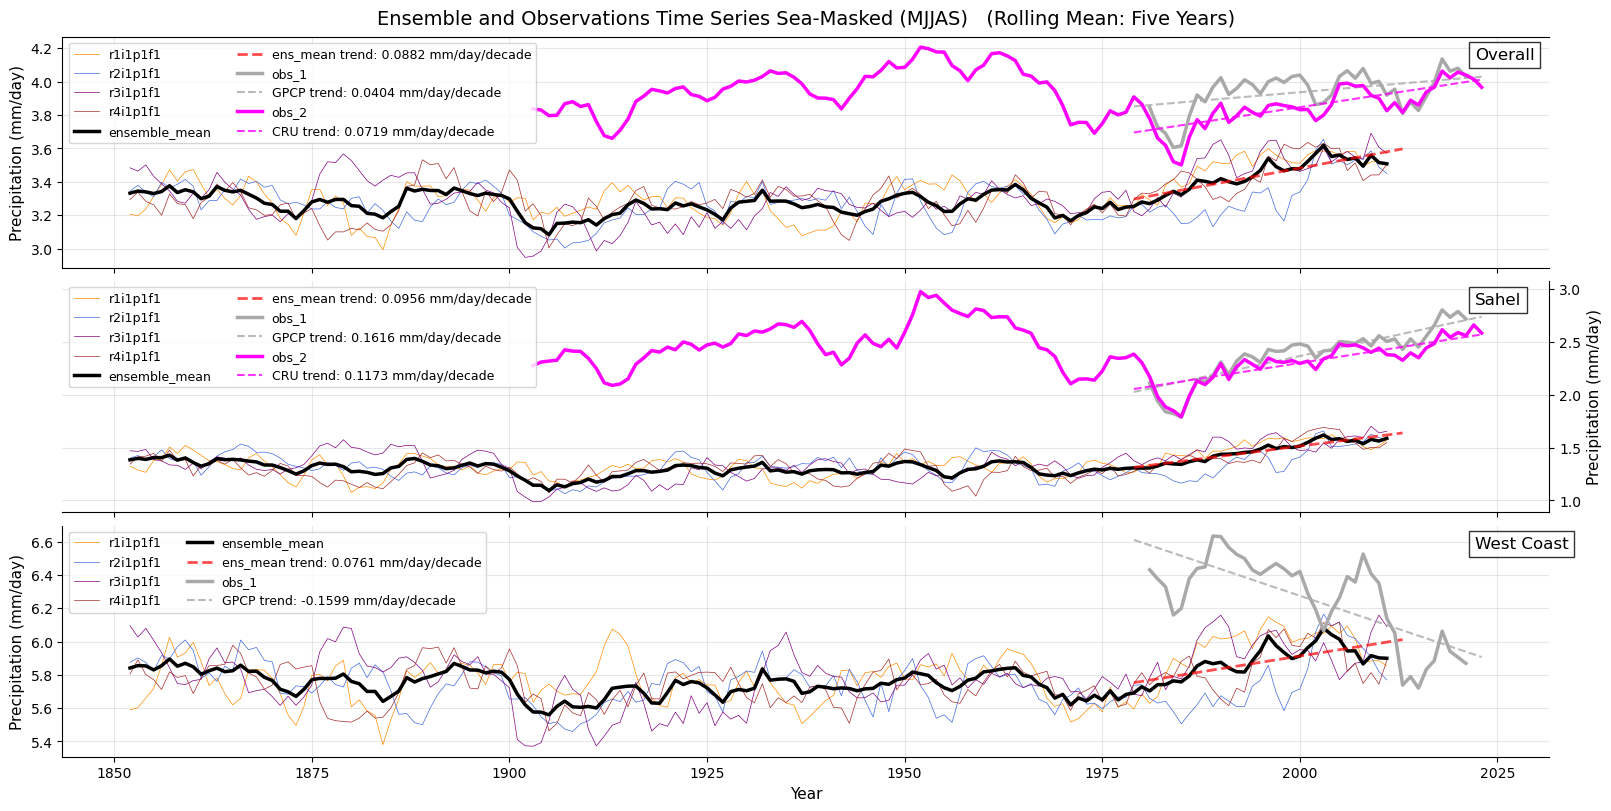

In [33]:
plot_time_series(regions_list, masked_ts, ens_colours)

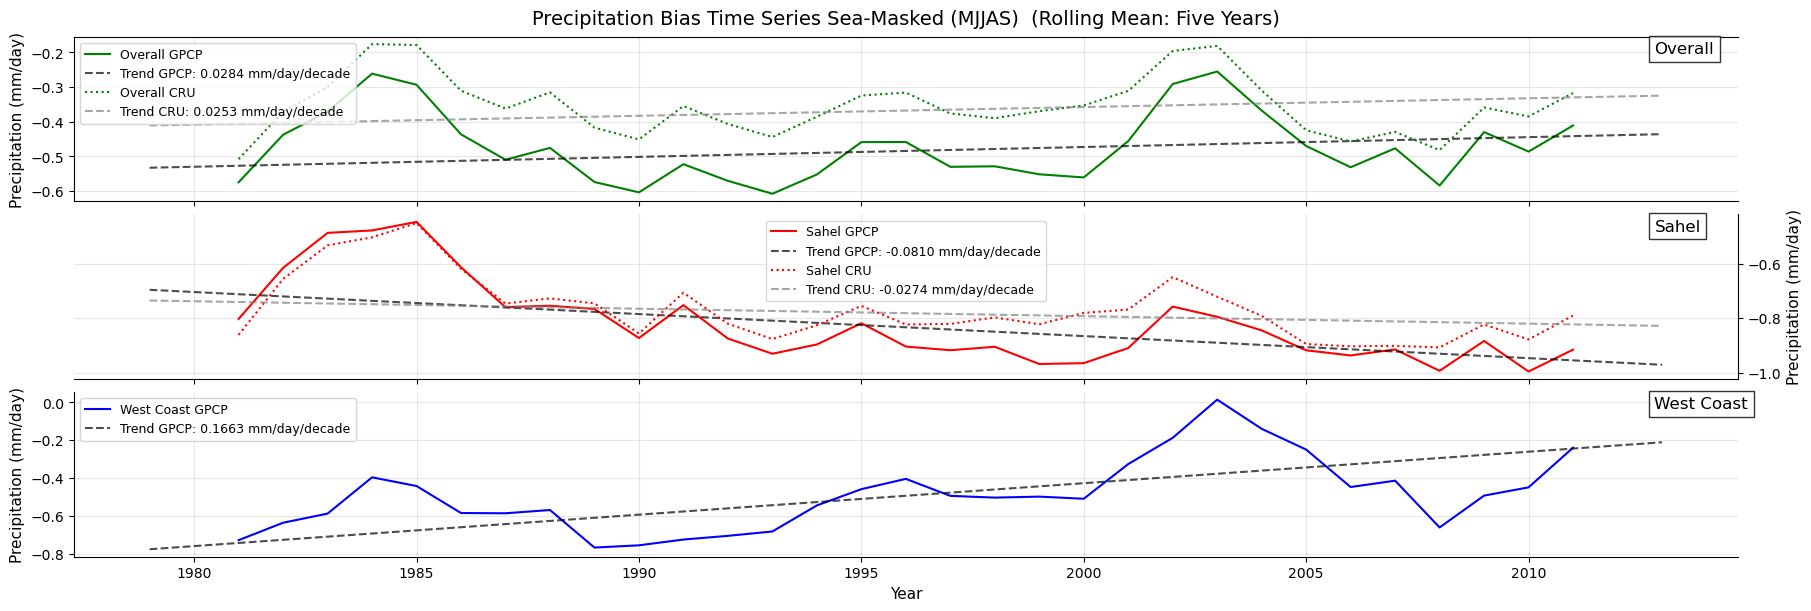

In [34]:
plot_pr_bias_series(regions_list, masked_bias_1, masked_bias_2, region_colours)

### Bias Statistical Significance

In [35]:
region_significance = {}

for region in regions_list:
    region_significance[region] = {}
    
    # Two observations
    for obs_name in ["obs_1", "obs_2"]:

        if region == "west_coast" and obs_name == "obs_2":
            region_significance[region][obs_name] = {
                'slope_first': np.nan,
                'slope_last': np.nan,
                'p_value_trend': np.nan,
                'trend_change_significant': False,
                'note': 'obs_2 not available for west_coast'
            }
            continue
        
        # Observation dataset
        obs_ts = masked_ts[region][obs_name]
        var_obs = list(obs_ts.data_vars)[0]
        y_obs_full = obs_ts[var_obs].values
        years_obs = obs_ts['year'].values

        # Model dataset (ensemble mean or whatever you want)
        ens_ts = masked_ts[region]['ensemble_mean']
        var_ens = list(ens_ts.data_vars)[0]
        y_ens_full = ens_ts[var_ens].values
        years_ens = ens_ts['year'].values

        # Common years
        common_years = np.intersect1d(years_obs, years_ens)

        y_obs = y_obs_full[np.isin(years_obs, common_years)]
        y_ens = y_ens_full[np.isin(years_ens, common_years)]
        years = common_years

        # Remove NaNs
        mask = (~np.isnan(y_obs)) & (~np.isnan(y_ens))
        y_obs = y_obs[mask]
        y_ens = y_ens[mask]
        years = years[mask]

        # Compute bias
        bias = y_ens - y_obs

        # First 15 years
        years_first = years[:20]
        bias_first  = bias[:20]

        # Last 15 years
        years_last = years[-20:]
        bias_last  = bias[-20:]
        
        # Fit trends
        coeff_first = np.polyfit(years_first, bias_first, 1)
        coeff_last  = np.polyfit(years_last,  bias_last,  1)

        slope_first = coeff_first[0]
        slope_last  = coeff_last[0]

        # Student t-test on bias values
        t_stat, p_val = ttest_ind(bias_first, bias_last, equal_var=False)

        region_significance[region][obs_name] = {
            'slope_first': slope_first,
            'slope_last': slope_last,
            'p_value_trend': p_val,
            'trend_change_significant': p_val < 0.05
        }


In [36]:
region_significance['overall']

{'obs_1': {'slope_first': np.float64(0.004373080748365576),
  'slope_last': np.float64(0.00409087543200804),
  'p_value_trend': np.float64(0.7200862863968398),
  'trend_change_significant': np.False_},
 'obs_2': {'slope_first': np.float64(0.005809728754352437),
  'slope_last': np.float64(-6.76203293320286e-05),
  'p_value_trend': np.float64(9.818067255395515e-05),
  'trend_change_significant': np.True_}}

In [37]:
region_significance['sahel']

{'obs_1': {'slope_first': np.float64(-0.009511638135836227),
  'slope_last': np.float64(0.0005107323029904412),
  'p_value_trend': np.float64(0.15860979660058347),
  'trend_change_significant': np.False_},
 'obs_2': {'slope_first': np.float64(0.007723540290802658),
  'slope_last': np.float64(0.0017726105698907823),
  'p_value_trend': np.float64(0.000949823454554299),
  'trend_change_significant': np.True_}}

In [38]:
region_significance['west_coast']

{'obs_1': {'slope_first': np.float64(0.019502976066188314),
  'slope_last': np.float64(0.012820948335460795),
  'p_value_trend': np.float64(0.03927803446172026),
  'trend_change_significant': np.True_},
 'obs_2': {'slope_first': nan,
  'slope_last': nan,
  'p_value_trend': nan,
  'trend_change_significant': False,
  'note': 'obs_2 not available for west_coast'}}

## Hovmöller Plot (All Ensemble)

### Filter Data

In [39]:
# Ensemble 
# Now we are interested in the same period as what we have in the observations.
# Period 1979-2014.
filtered_ens_files = {}

# Make sure that all ensemble members have start and end (same or similar) within the timeframe.
# Convert units beforehand also.
for ens in ensemble_members:
    filtered_ens_files[ens] = interpolated_model_files[ens].sel(time=slice("1979-01-01", "2015-01-01")) * 86400
    print(f"\n{ens} Start:", filtered_ens_files[ens].time.min().values)
    print(f"{ens} End:", filtered_ens_files[ens].time.max().values)
    print(f"{ens} Number of time steps:", filtered_ens_files[ens].time.size)


r1i1p1f1 Start: 1979-01-16 00:00:00
r1i1p1f1 End: 2014-12-16 00:00:00
r1i1p1f1 Number of time steps: 432

r2i1p1f1 Start: 1979-01-16 00:00:00
r2i1p1f1 End: 2014-12-16 00:00:00
r2i1p1f1 Number of time steps: 432

r3i1p1f1 Start: 1979-01-16 00:00:00
r3i1p1f1 End: 2014-12-16 00:00:00
r3i1p1f1 Number of time steps: 432

r4i1p1f1 Start: 1979-01-16 00:00:00
r4i1p1f1 End: 2014-12-16 00:00:00
r4i1p1f1 Number of time steps: 432


In [40]:
# Observations
filtered_obs = obs_file.sel(time=slice("1979-01-01", "2015-01-01"))

print("Start:", filtered_obs.time.min().values)
print("End:", filtered_obs.time.max().values)
print("Number of time steps:", filtered_obs.time.size)

Start: 19790101.0
End: 20141201.0
Number of time steps: 432


### Monthly Average

In [41]:
def model_hovmoller_monthly_average(data):
    # Average monthly climatology
    monthly_hov_avg = data.groupby('time.month').mean(dim='time')
    return monthly_hov_avg

def obs_hovmoller_monthly_average(data):
    # Ensure time is datetime
    data = data.assign_coords(time=pd.to_datetime(data['time'].astype(int).astype(str), format='%Y%m%d'))
    # Monthly climatology
    monthly_hov_avg = data.groupby('time.month').mean(dim='time')
    return monthly_hov_avg

In [42]:
monthly_avg_hov = {}

names = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'obs']
hov_files = [filtered_ens_files[names[0]],
            filtered_ens_files[names[1]],
            filtered_ens_files[names[2]],
            filtered_ens_files[names[3]]]

for (name, i) in zip(names, range(len(names)-1)):
    monthly_avg_hov[name] = model_hovmoller_monthly_average(hov_files[i])

In [43]:
hov_data = {}
hov_data['obs'] = obs_hovmoller_monthly_average(filtered_obs)

### Compute Ensemble Mean

In [44]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='pr'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [45]:
hov_ensemble_mean = compute_ensemble_mean(ensemble_members, monthly_avg_hov)
hov_data['ensemble_mean'] = hov_ensemble_mean
hov_data['ensemble_mean']

<xarray.DataArray 'pr' (month: 12, latitude: 72, longitude: 144)> Size: 498kB
dask.array<mean_agg-aggregate, shape=(12, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [46]:
# Select longitudes.
# These are the same longitude and latitude values used in the boxing map.
lon_min, lon_max = -20, 20
lat_min, lat_max = -5, 20
names = ['obs', 'ensemble_mean']

for (name, i) in zip(names, range(len(names))):
    # Filter values via slicing.
    hov_data[name] = hov_data[name].sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    # Compute zonal mean.
    hov_data[name] = hov_data[name].mean('longitude')

In [47]:
# Compute anomaly.
hov_data['bias'] = hov_data['ensemble_mean'] - hov_data['obs']['precip']
hov_data['bias']

<xarray.DataArray (month: 12, latitude: 10)> Size: 480B
dask.array<sub, shape=(12, 10), dtype=float32, chunksize=(1, 10), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float32 40B -3.75 -1.25 1.25 3.75 ... 13.75 16.25 18.75
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

### Plot

In [48]:
hov_data['bias'].transpose('latitude', 'month')

<xarray.DataArray (latitude: 10, month: 12)> Size: 480B
dask.array<transpose, shape=(10, 12), dtype=float32, chunksize=(10, 1), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float32 40B -3.75 -1.25 1.25 3.75 ... 13.75 16.25 18.75
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

### Compute Precipitation Zonal Mean

100%|█████████████████████████████| 2/2 [00:00<00:00, 13.89it/s]


Start: 1979-01-16 00:00:00
End: 2014-12-16 00:00:00
Number of time steps: 432
[[[0.12758222 0.10969746 0.10829124 ... 0.12171717 0.1253801  0.12970419]
  [0.11629204 0.12142039 0.12498142 ... 0.09626419 0.09679327 0.10955632]
  [0.14171085 0.12462636 0.09429074 ... 0.10510474 0.10180674 0.10287374]
  ...
  [0.09270998 0.09070669 0.09063374 ... 0.1874747  0.13638665 0.10205264]
  [0.18210024 0.18424635 0.18725039 ... 0.18114926 0.18007131 0.18072708]
  [0.25666234 0.2588291  0.2604369  ... 0.24842383 0.25153407 0.25421005]]

 [[0.13095662 0.1299643  0.12844531 ... 0.13309114 0.13250877 0.13127987]
  [0.16071281 0.16338103 0.1647535  ... 0.15480442 0.15644735 0.1581018 ]
  [0.22346559 0.2184268  0.21270144 ... 0.22805172 0.22874549 0.22769608]
  ...
  [1.5001417  1.4277018  1.3618201  ... 1.5032634  1.4985906  1.6059375 ]
  [0.9121067  0.90120107 0.89485925 ... 0.9705592  0.9385446  0.91759956]
  [0.64660925 0.64208853 0.63672054 ... 0.65673894 0.6547202  0.65138376]]]
Start: 19790101.0


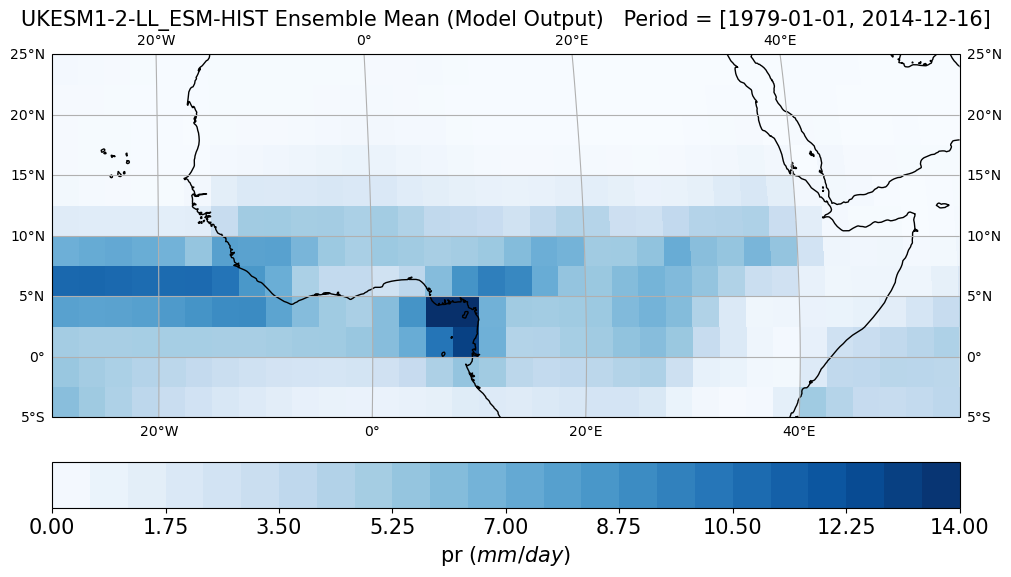

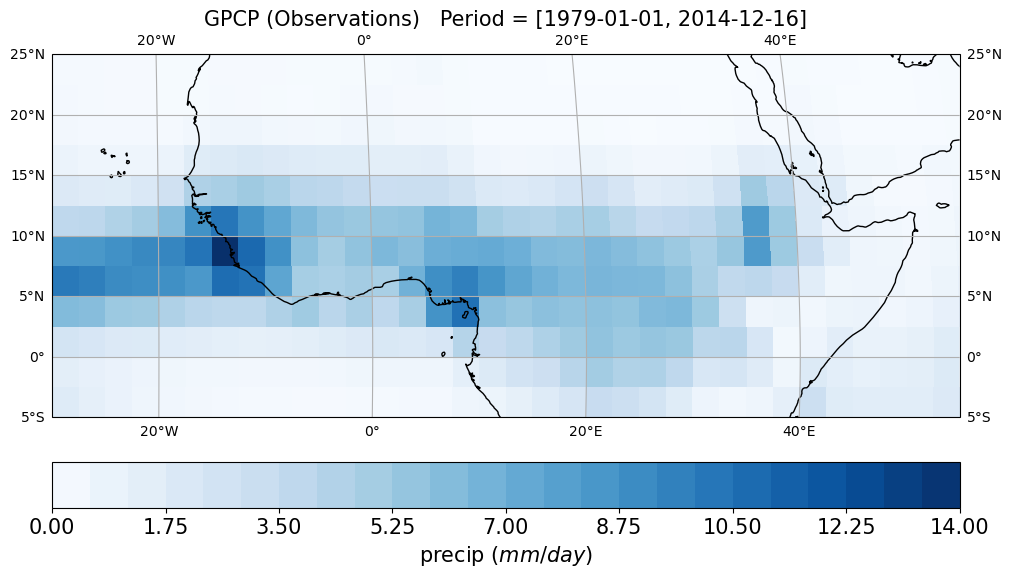

{'standard_deviation': 1.2445948123931885, 'min': -7.419381141662598, 'max': 18.28880500793457}


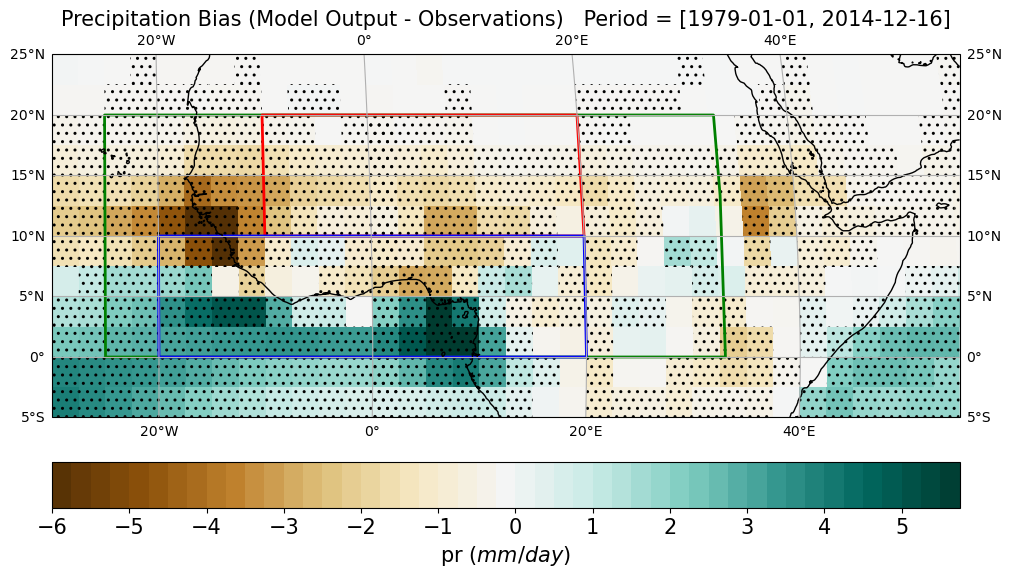

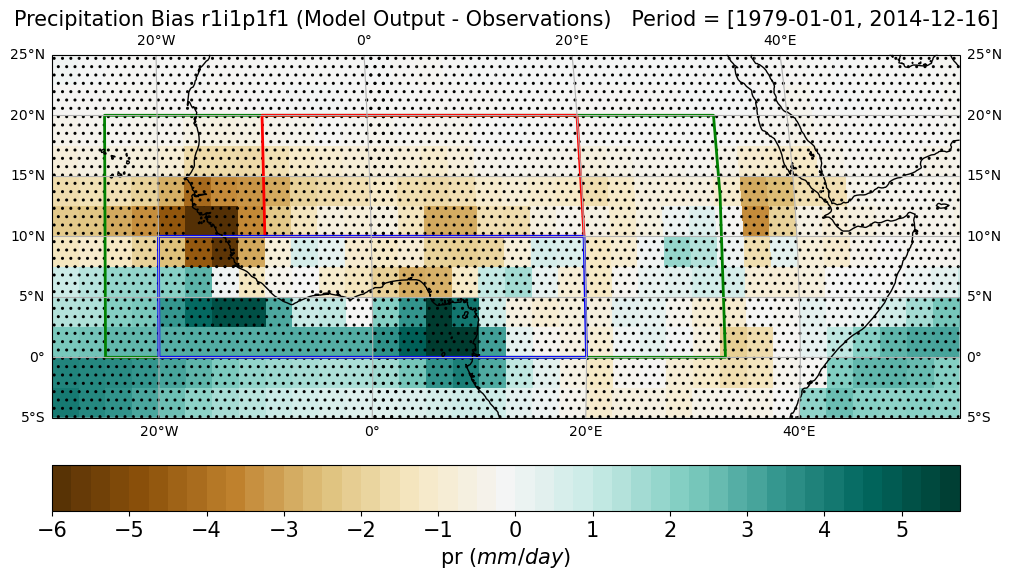

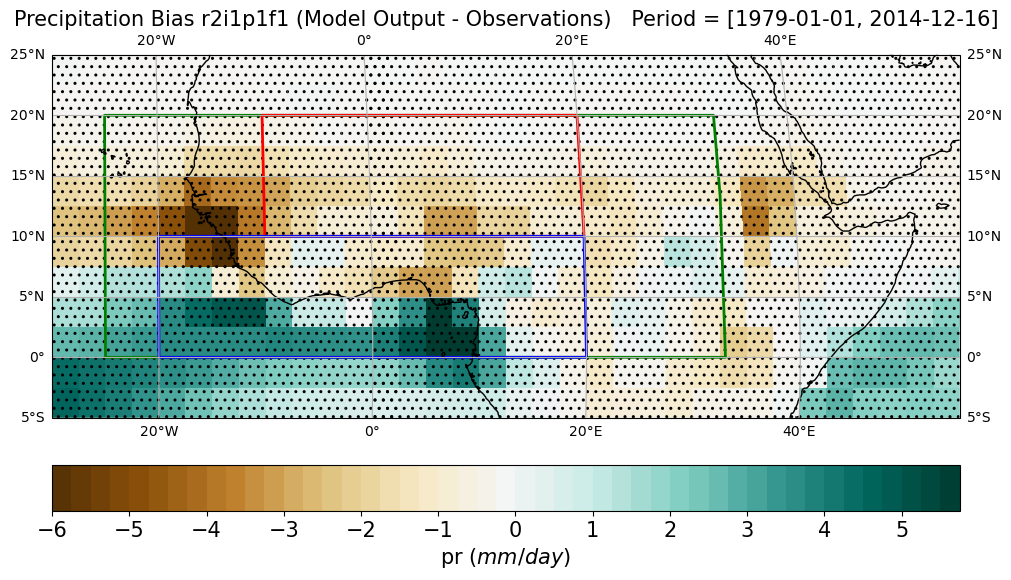

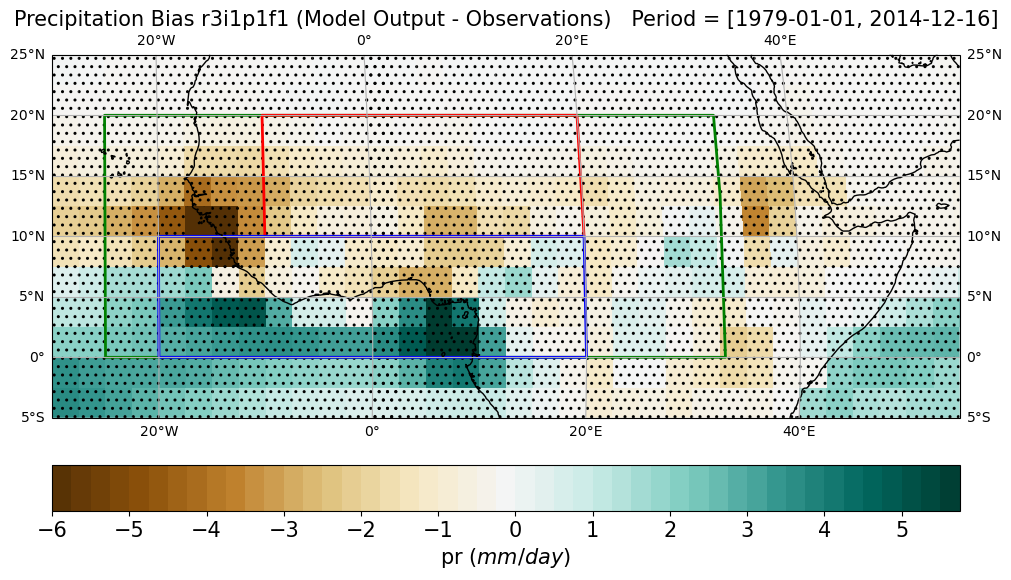

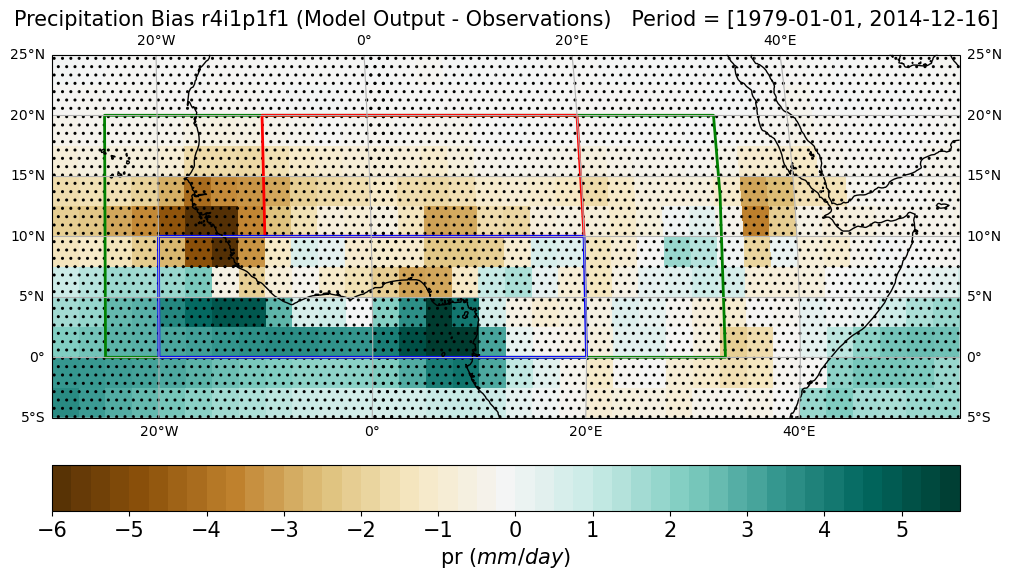

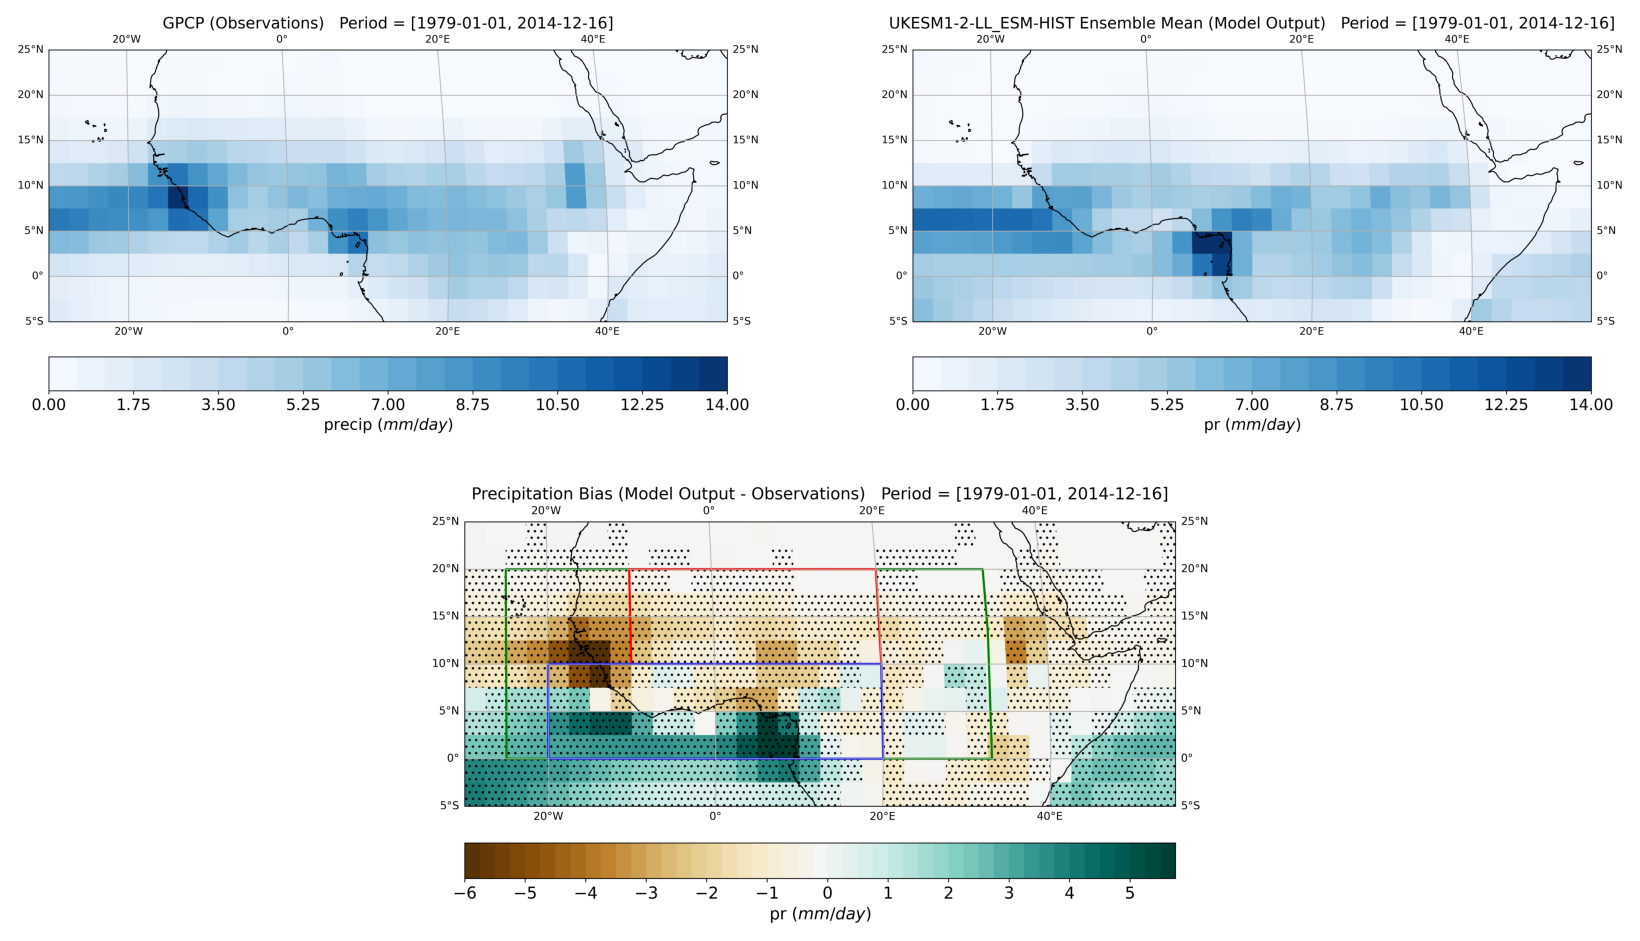

In [49]:
# Run precipitation Jupyter notebook.
# Located in the same directory as this notebook.
# Filename: precipitation_1
%run model_bias_analysis_precipitation_1_climatology_ts_hovmoller.ipynb

In [50]:
precip_zonal_mean = filtered_obs.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
precip_zonal_mean = precip_zonal_mean.mean('longitude')
precip_zonal_mean['precip']

<xarray.DataArray 'precip' (time: 432, latitude: 10)> Size: 17kB
dask.array<mean_agg-aggregate, shape=(432, 10), dtype=float32, chunksize=(1, 10), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) float64 3kB 1.979e+07 1.979e+07 ... 2.014e+07 2.014e+07
  * latitude  (latitude) float32 40B -3.75 -1.25 1.25 3.75 ... 13.75 16.25 18.75

In [51]:
def ensemble_hov_plot(data_dict, precip_obs, names):

    fig = plt.figure(figsize=(13, 8), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax1 = fig.add_axes([0.05, 0.55, 0.42, 0.40]) 
    ax2 = fig.add_axes([0.53, 0.55, 0.42, 0.40])
    ax3 = fig.add_axes([0.28, 0.05, 0.44, 0.40])

    axes = [ax1, ax2, ax3]
    cs = []

    for i, name in enumerate(names):
        ds = data_dict[name]

        # Extract correct DataArray
        if isinstance(ds, xr.Dataset):
            data = ds['precip'] 
        else:
            data = ds     

        # Transpose to (latitude, month)
        data_t = data.transpose('latitude', 'month')

        # Compute vmin/vmax
        vmin = float(data_t.min())
        vmax = float(data_t.max())

        # Plot
        # Bias Hovmoller has BrBG colour palette.
        if i == 2:
            cs_i = axes[i].contourf(data_t['month'], data_t['latitude'], data_t.values,
                                    levels=np.arange(-5, 5, 0.25), cmap='BrBG',
                                    vmin=vmin, vmax=vmax)

            if not np.issubdtype(precip_obs['time'].dtype, np.datetime64):

                time_values = precip_obs['time'].values.astype(int).astype(str)
            
                precip_obs = precip_obs.assign_coords(time=pd.to_datetime(time_values, format='%Y%m%d'))
            
            # Calculate monthly climatology
            precip_obs_monthly = (precip_obs.groupby('time.month').mean('time'))

            # Ensure correct orientation
            precip_obs_t = precip_obs_monthly.transpose('latitude', 'month')

            # Contour levels
            precip_levels = np.arange(1, 15, 1)
            precip_contours = axes[i].contour(precip_obs_t['month'], precip_obs_t['latitude'], 
                                              precip_obs_t.values, levels=precip_levels, colors='blue',
                                              linewidths=0.8)
        
            # Add contour labels
            axes[i].clabel(precip_contours, inline=True, fontsize=8, fmt='%d')
            
        else:
            cs_i = axes[i].contourf(data_t['month'], data_t['latitude'], data_t.values,
                                    levels=np.arange(vmin, vmax+1, 0.2), cmap='Blues',
                                    vmin=vmin, vmax=vmax+1)
        cs.append(cs_i)

        # Formatting
        axes[i].set_xticks(np.arange(1, 13))
        axes[i].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
        axes[i].set_xlabel('Month', fontsize=10)
        axes[i].set_ylabel('Latitude', fontsize=10)

    # Titles
    ax1.set_title('GPCP (Observations)', fontsize=13)
    ax2.set_title('UKESM1-2-LL_ESM-HIST Ensemble Mean (Model Output)', fontsize=13)
    ax3.set_title('Precipitation Bias', fontsize=13)
    
    # Shared colourbar (top)
    cbar_top = fig.colorbar(cs[0], ax=[ax1, ax2], pad=0.02, location='right')
    cbar_top.set_label('Precipitation (mm/day)', fontsize=10)

    # Bias colourbar
    cbar_bottom = fig.colorbar(cs[2], ax=ax3, pad=0.02, location='right')
    cbar_bottom.set_label('Precipitation (mm/day)', fontsize=10)

    plt.savefig('/home/users/alvin_ch/figures/Multi-model/UKESM/Precip/HP-pr_Ensemble_Bias.png', dpi=450)
    plt.show()


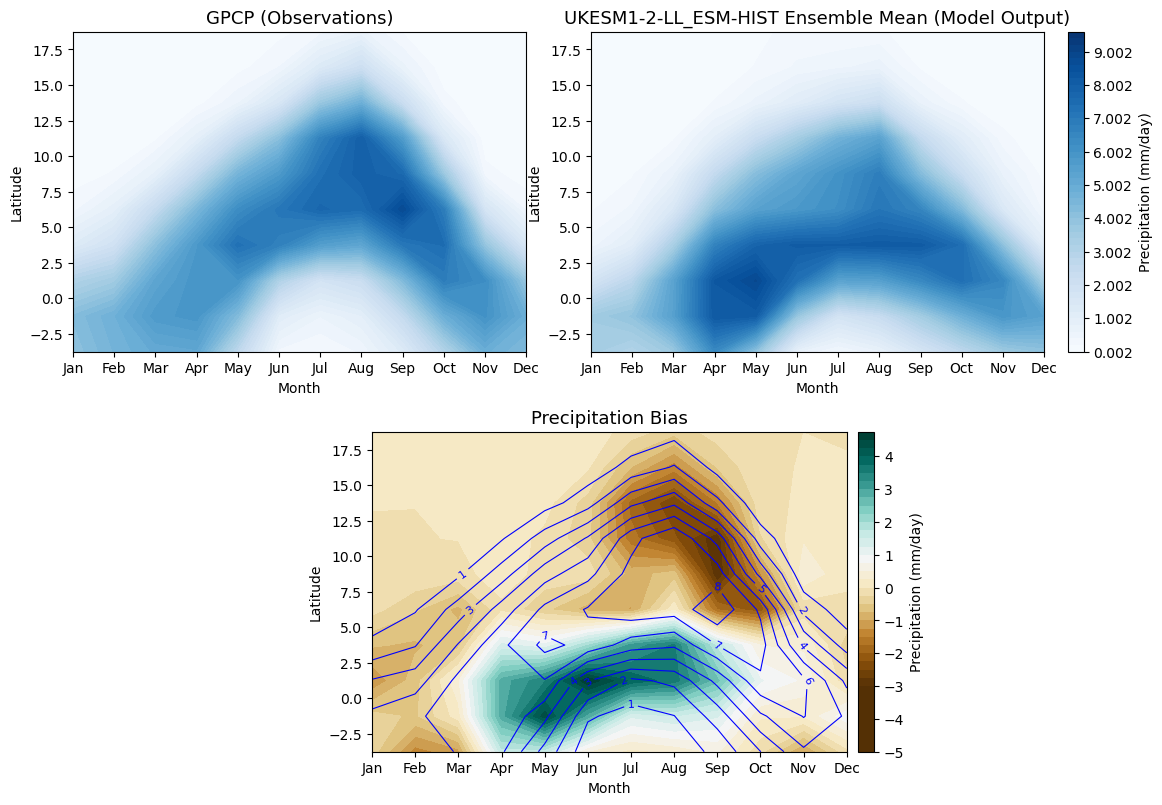

In [52]:
names = ['obs', 'ensemble_mean', 'bias']
ensemble_hov_plot(hov_data, precip_zonal_mean['precip'], names)